# Week 2-3 Listing Dataset EDA

This notebook documents exploratory data analysis for the CRMLS listing dataset.

Goals:
- Inspect rows, columns, and data types
- Review property types and Residential filtering logic
- Calculate missing counts and missing percentages
- Flag columns with more than 90% missing values
- Separate market analysis fields from metadata fields
- Review numeric distributions and outliers
- Save reports and a filtered analysis dataset

## 1. Import Packages And Set Paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "data" / "reports" / "week2_3_listing_eda"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

LISTING_FILE = PROCESSED_DIR / "crmls_listings_combined_residential_202401_202605.csv"
LISTING_FILE

PosixPath('/Users/baixuezhang/Documents/IDX Exchange/real-estate-dashboard-project/data/processed/crmls_listings_combined_residential_202401_202605.csv')

## 2. Load The Listing Dataset

This file was created in Week 1 by concatenating monthly listing CSVs and filtering to `PropertyType == "Residential"`.

In [2]:
listings = pd.read_csv(LISTING_FILE, low_memory=False)

print(f"Rows: {listings.shape[0]:,}")
print(f"Columns: {listings.shape[1]:,}")
listings.head()

Rows: 591,409
Columns: 84


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


## 3. Inspect Structure

In [3]:
listings.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [4]:
dtypes_summary = listings.dtypes.astype(str).reset_index()
dtypes_summary.columns = ["column", "dtype"]
dtypes_summary

,column,dtype
0,OriginalListPrice,float64
1,ListingKey,int64
2,ListAgentEmail,str
3,CloseDate,str
4,ClosePrice,float64
...,...,...
79,BuyerOfficeName.1,str
80,AssociationFee,float64
81,LotSizeSquareFeet,float64
82,MiddleOrJuniorSchoolDistrict,float64


## 4. Review Property Types

Because this processed file is already Residential-filtered, we expect only Residential rows here. If you need Residential vs. other property type share, use raw monthly files or save an unfiltered combined listing dataset.

In [5]:
property_type_counts = listings["PropertyType"].fillna("Missing").value_counts(dropna=False)
property_type_counts

PropertyType
Residential    591409
Name: count, dtype: int64

## 5. Missing Value Analysis

In [7]:
missing_report = pd.DataFrame({
    "column": listings_residential.columns,
    "missing_count": listings_residential.isna().sum().values,
})

missing_report["missing_pct"] = (
    missing_report["missing_count"] / len(listings_residential) * 100
).round(2)
missing_report["over_90_pct_missing"] = missing_report["missing_pct"] > 90
missing_report = missing_report.sort_values("missing_pct", ascending=False)

missing_report.head(25)

,column,missing_count,missing_pct,over_90_pct_missing
28,TaxAnnualAmount,591409,100.00,True
23,FireplacesTotal,591409,100.00,True
55,ElementarySchoolDistrict,591409,100.00,True
50,TaxYear,591409,100.00,True
60,BusinessType,591409,100.00,True
82,MiddleOrJuniorSchoolDistrict,591409,100.00,True
64,CoveredSpaces,591409,100.00,True
25,AboveGradeFinishedArea,591409,100.00,True
59,BelowGradeFinishedArea,588037,99.43,True
56,CoBuyerAgentFirstName,576759,97.52,True


In [8]:
high_missing_columns = missing_report[missing_report["over_90_pct_missing"]]
high_missing_columns

,column,missing_count,missing_pct,over_90_pct_missing
28,TaxAnnualAmount,591409,100.00,True
23,FireplacesTotal,591409,100.00,True
55,ElementarySchoolDistrict,591409,100.00,True
50,TaxYear,591409,100.00,True
60,BusinessType,591409,100.00,True
82,MiddleOrJuniorSchoolDistrict,591409,100.00,True
64,CoveredSpaces,591409,100.00,True
25,AboveGradeFinishedArea,591409,100.00,True
59,BelowGradeFinishedArea,588037,99.43,True
56,CoBuyerAgentFirstName,576759,97.52,True


## 6. Market Analysis Fields Vs Metadata Fields

In [9]:
core_market_fields = {
    "ListingKey", "ListingId", "ListingContractDate", "ContractStatusChangeDate",
    "ListPrice", "OriginalListPrice", "PropertyType", "PropertySubType",
    "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt", "CountyOrParish", "City", "PostalCode",
    "Latitude", "Longitude", "MlsStatus",
}

metadata_fields = {
    "ListingKeyNumeric", "ListAgentEmail", "ListAgentFirstName",
    "ListAgentLastName", "ListAgentFullName", "CoListAgentFirstName",
    "CoListAgentLastName", "BuyerAgentMlsId", "BuyerAgentFirstName",
    "BuyerAgentLastName", "ListOfficeName", "BuyerOfficeName",
    "CoListOfficeName", "BuyerOfficeAOR",
}

field_classification = []
for column in listings_residential.columns:
    base_column = column.replace(".1", "")
    if base_column in metadata_fields:
        category = "metadata"
    elif base_column in core_market_fields:
        category = "market_analysis_core"
    else:
        category = "market_analysis_other"
    field_classification.append({"column": column, "field_category": category})

field_classification = pd.DataFrame(field_classification)
field_classification

,column,field_category
0,OriginalListPrice,market_analysis_core
1,ListingKey,market_analysis_core
2,ListAgentEmail,metadata
3,CloseDate,market_analysis_other
4,ClosePrice,market_analysis_other
...,...,...
79,BuyerOfficeName.1,metadata
80,AssociationFee,market_analysis_other
81,LotSizeSquareFeet,market_analysis_other
82,MiddleOrJuniorSchoolDistrict,market_analysis_other


## 7. Numeric Distribution Summary

In [10]:
numeric_fields = [
    "ListPrice", "OriginalListPrice", "LivingArea", "LotSizeAcres",
    "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt",
]

numeric_summary_rows = []

for field in numeric_fields:
    series = pd.to_numeric(listings_residential[field], errors="coerce")
    percentiles = series.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    numeric_summary_rows.append({
        "field": field,
        "count": int(series.count()),
        "missing_count": int(series.isna().sum()),
        "min": series.min(),
        "max": series.max(),
        "mean": series.mean(),
        "median": series.median(),
        "p01": percentiles.loc[0.01],
        "p05": percentiles.loc[0.05],
        "p25": percentiles.loc[0.25],
        "p50": percentiles.loc[0.5],
        "p75": percentiles.loc[0.75],
        "p95": percentiles.loc[0.95],
        "p99": percentiles.loc[0.99],
    })

numeric_summary = pd.DataFrame(numeric_summary_rows)
numeric_summary

,field,count,missing_count,min,max,mean,median,p01,p05,p25,p50,p75,p95,p99
0,ListPrice,591409,0,1.0,4.000000e+08,1.318434e+06,848888.00,211999.08,345000.0000,580774.00,848888.00,1.385000e+06,3.465000e+06,8.250000e+06
1,OriginalListPrice,590567,842,0.0,1.390000e+09,1.402465e+06,849000.00,200000.00,348000.0000,585000.00,849000.00,1.395000e+06,3.495000e+06,8.500000e+06
2,LivingArea,590807,602,0.0,1.702132e+07,1.980152e+03,1672.00,588.00,817.0000,1248.00,1672.00,2.302000e+03,3.872000e+03,6.308940e+03
3,LotSizeAcres,542854,48555,0.0,4.187292e+06,6.143725e+01,0.17,0.00,0.0287,0.12,0.17,3.161000e-01,3.623700e+00,1.353210e+01
4,BedroomsTotal,591247,162,0.0,9.400000e+01,3.226748e+00,3.00,1.00,2.0000,2.00,3.00,4.000000e+00,5.000000e+00,6.000000e+00
5,BathroomsTotalInteger,591352,57,0.0,2.208000e+03,2.630207e+00,2.00,1.00,1.0000,2.00,2.00,3.000000e+00,5.000000e+00,7.000000e+00
6,DaysOnMarket,591409,0,-58.0,1.063000e+03,1.869106e+01,11.00,0.00,0.0000,5.00,11.00,2.200000e+01,6.800000e+01,1.350000e+02
7,YearBuilt,590392,1017,1776.0,2.028000e+03,1.979686e+03,1980.00,1911.00,1929.0000,1961.00,1980.00,2.001000e+03,2.023000e+03,2.025000e+03


## 8. Histograms And Boxplots

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


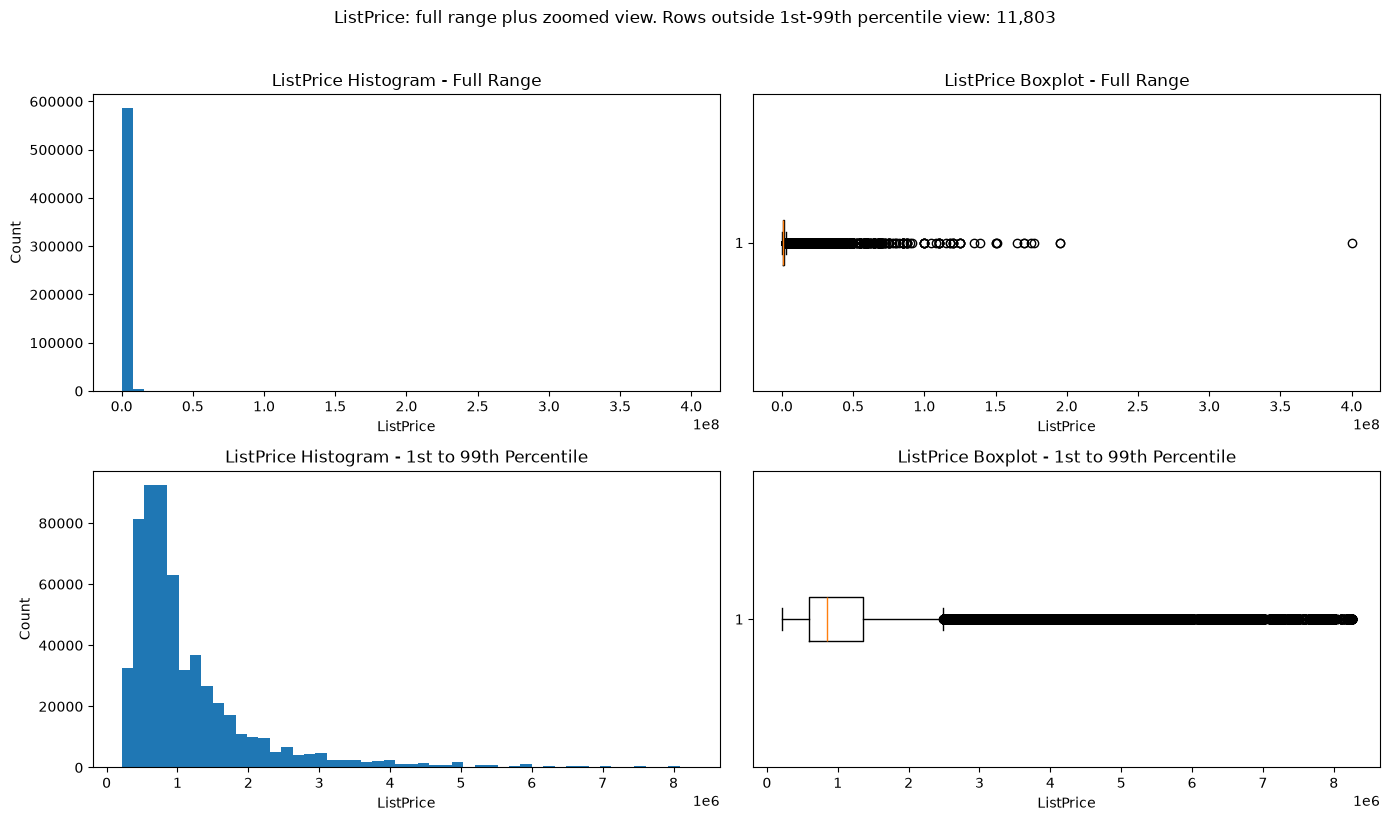

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


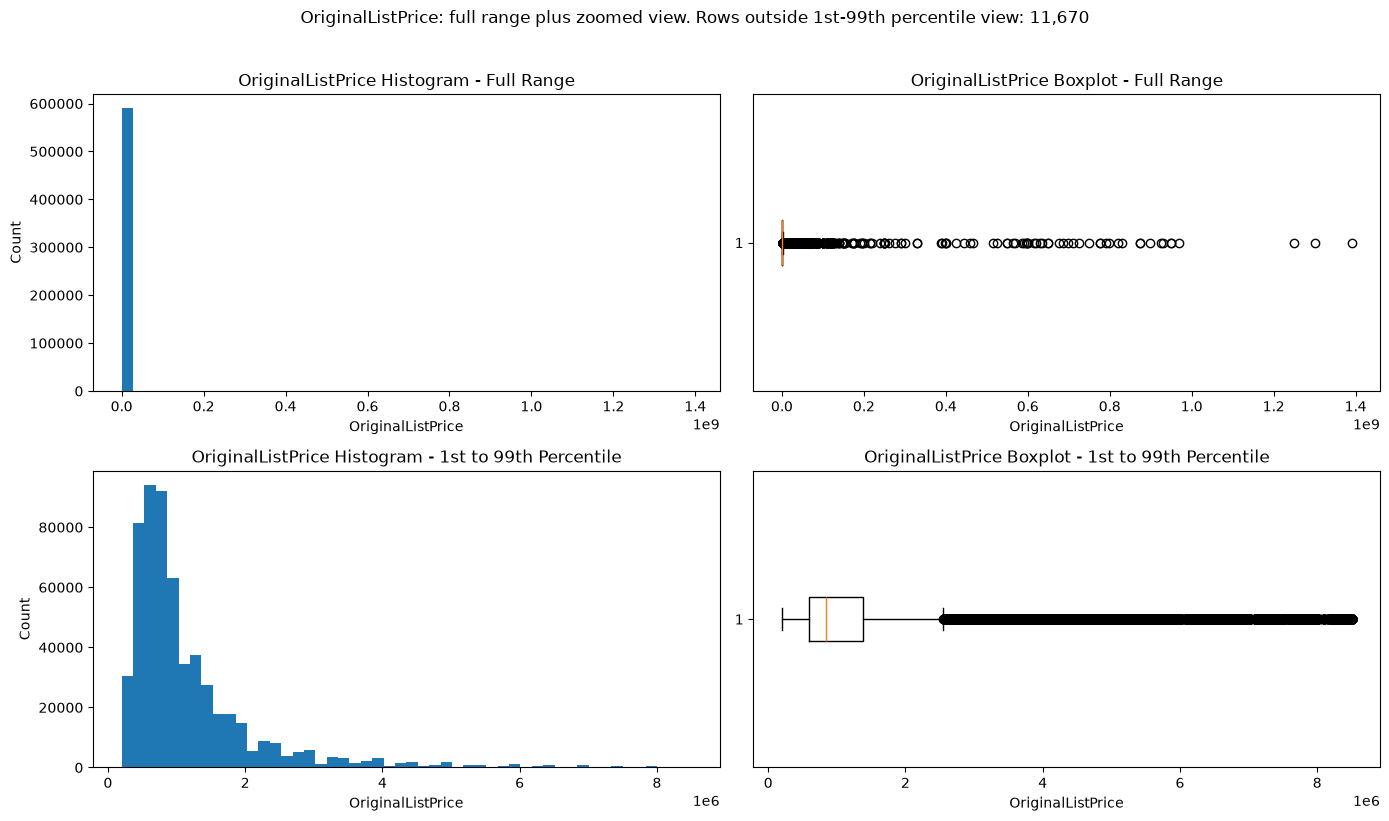

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


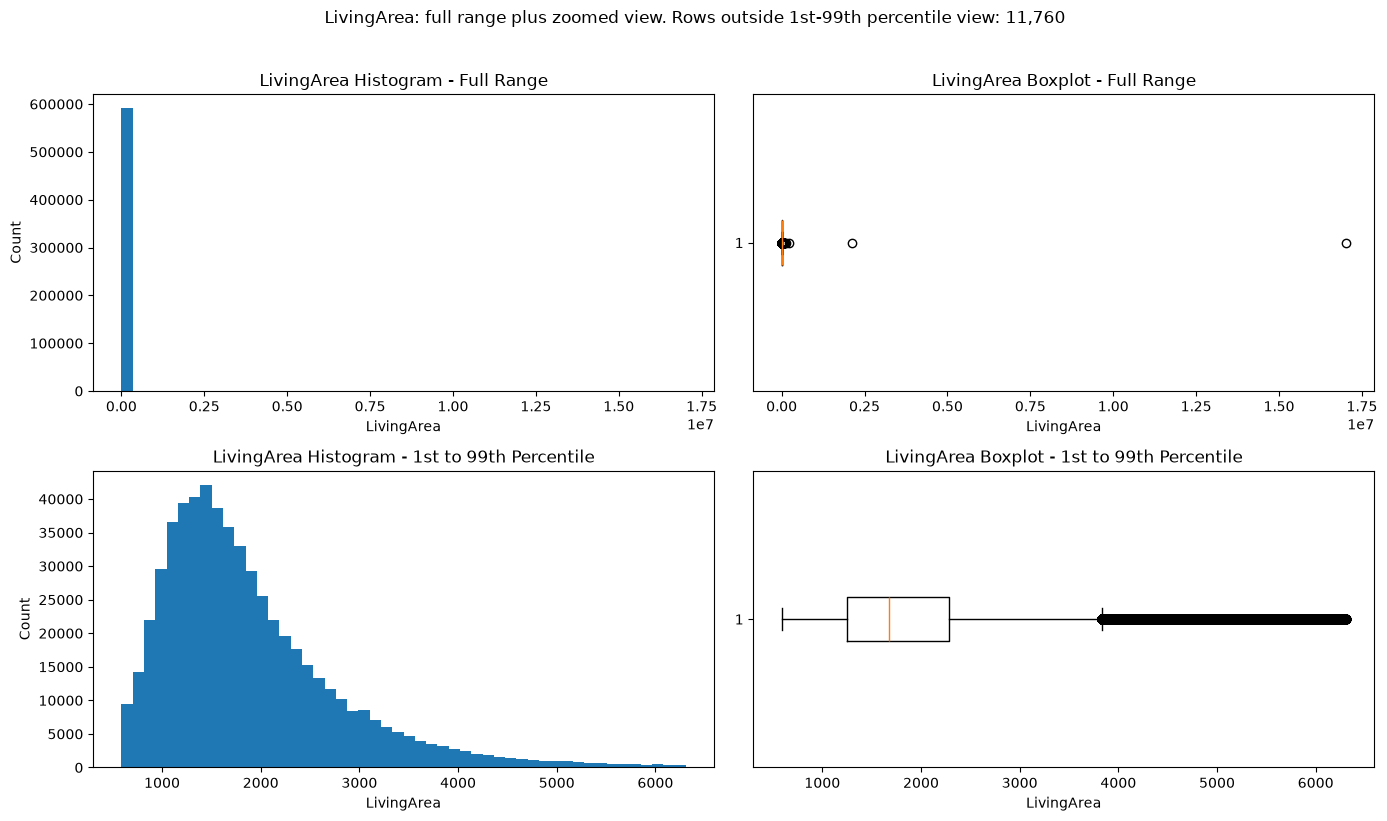

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


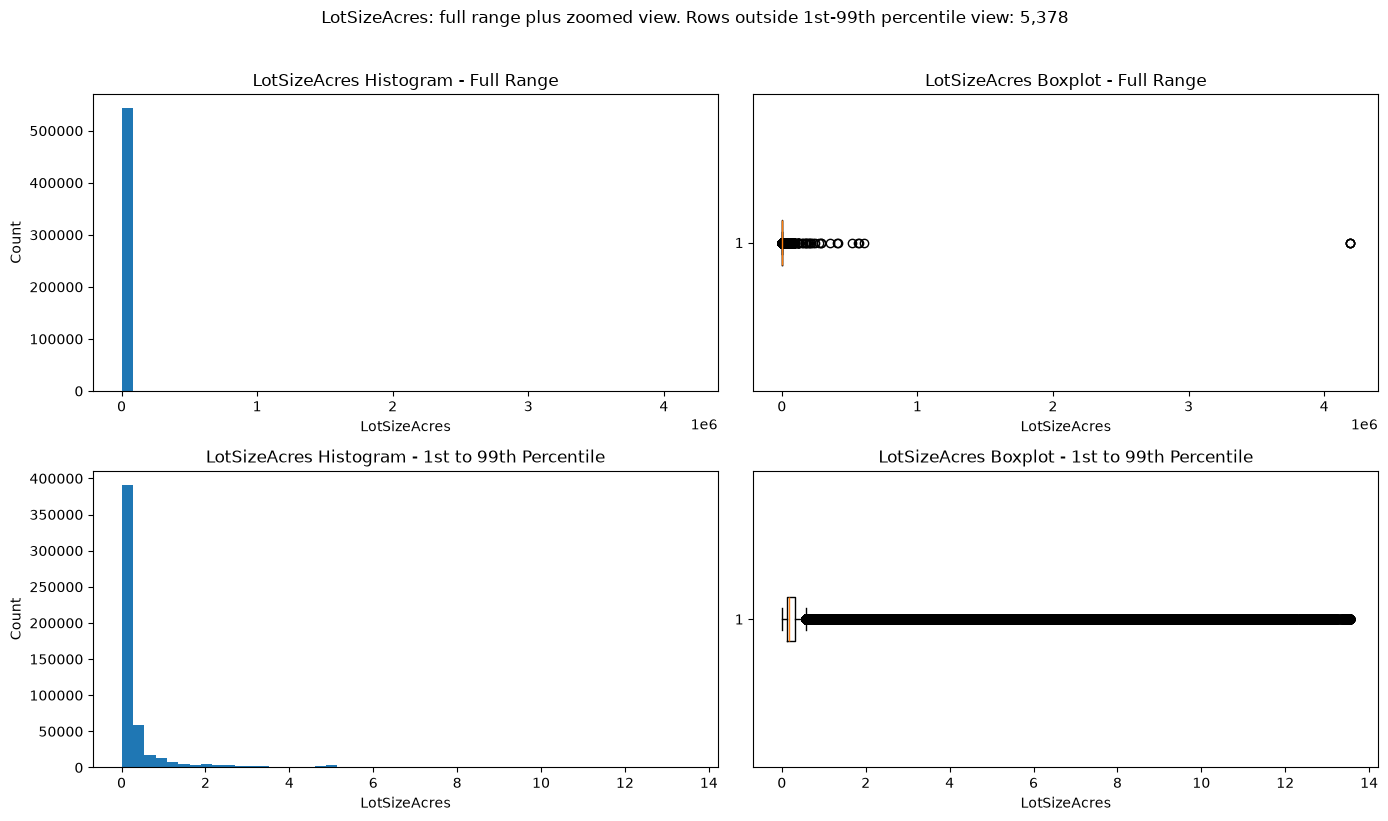

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


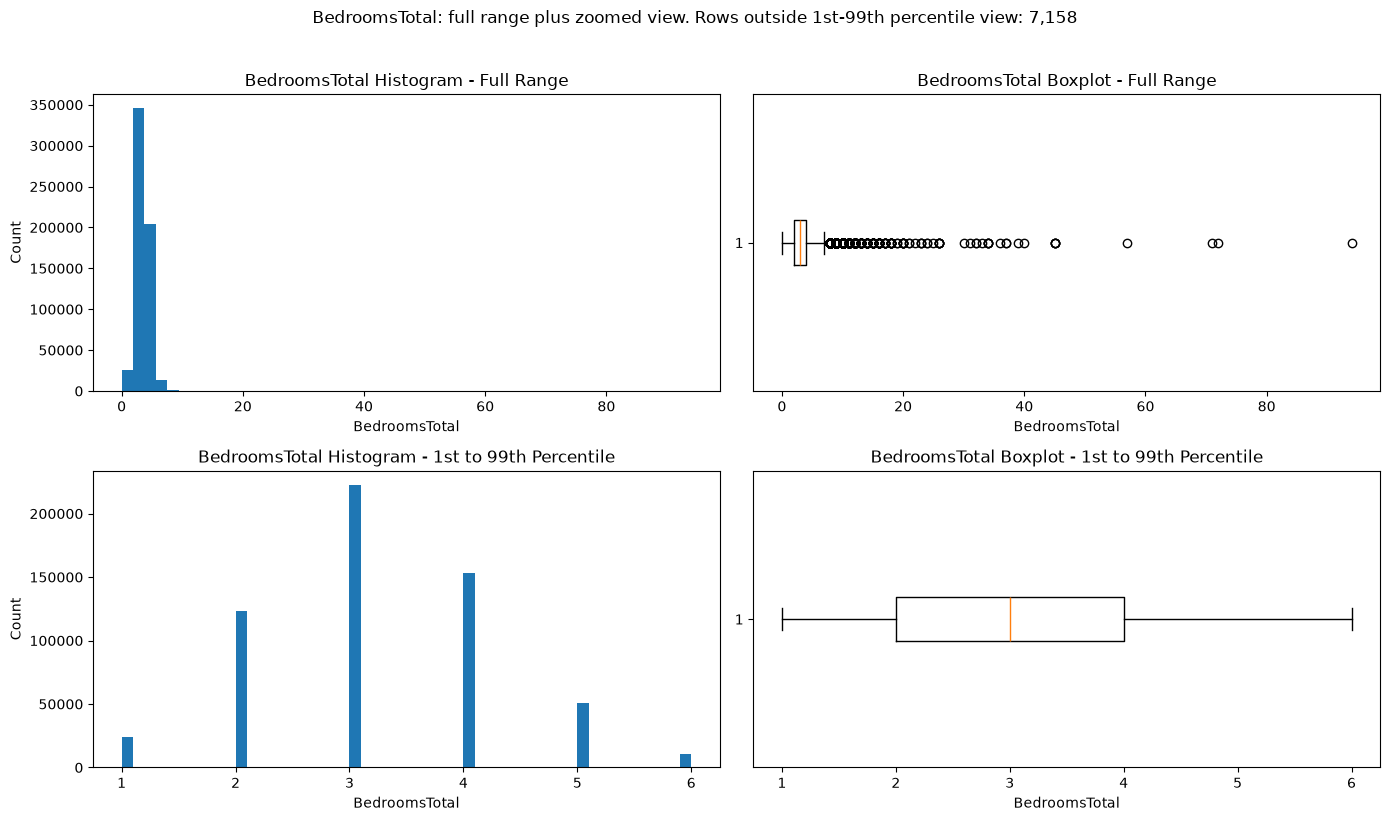

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


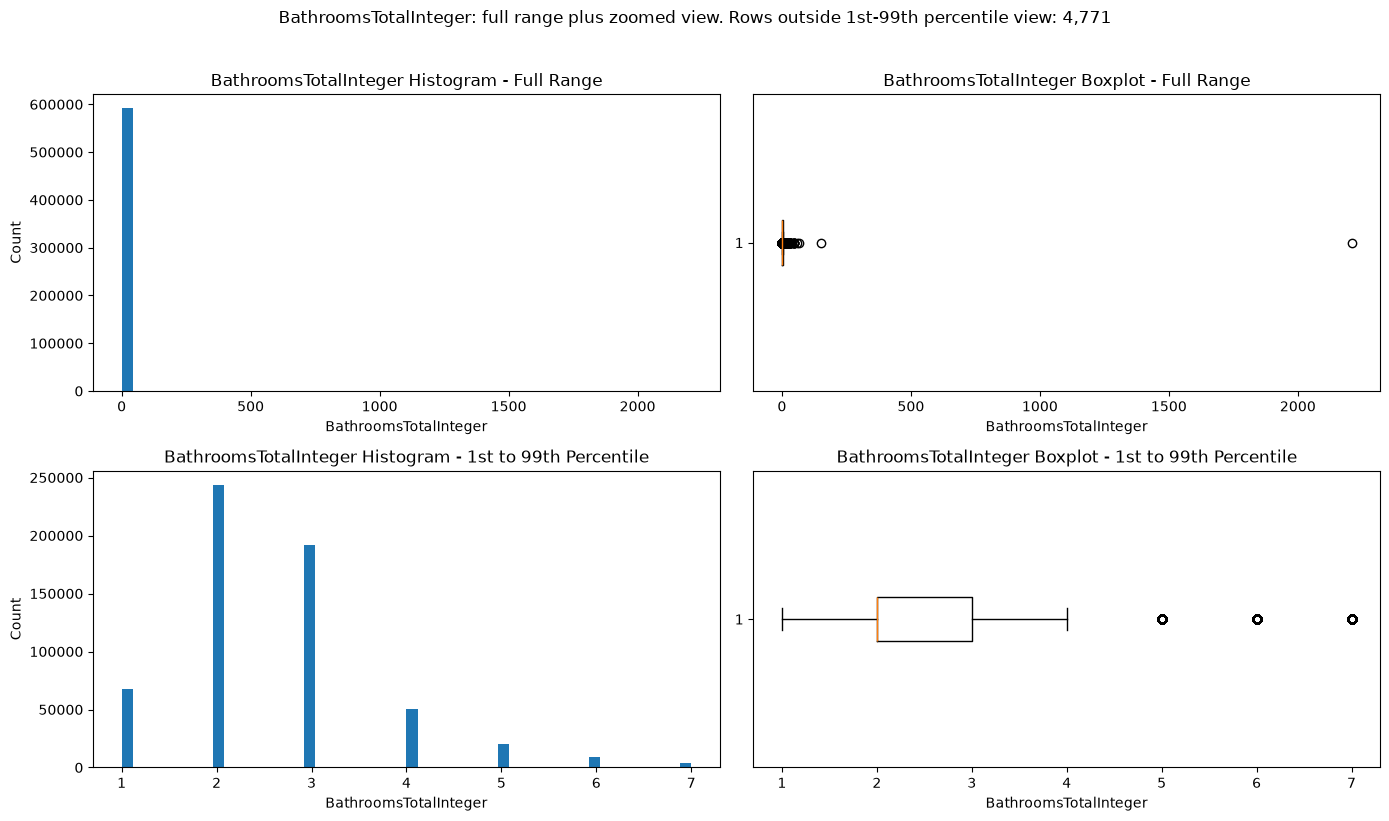

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


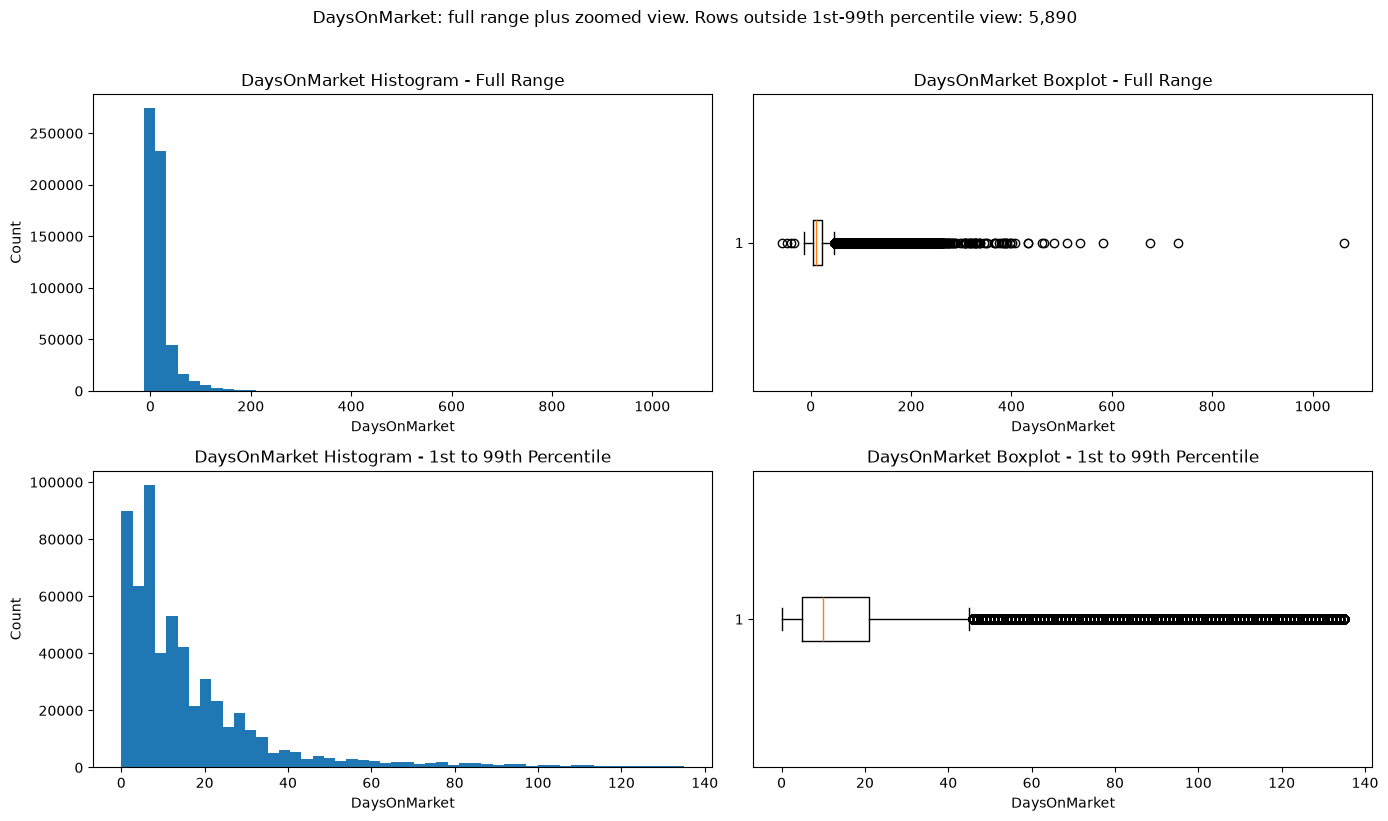

/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(series, vert=False, showfliers=True)
/var/folders/4r/7lbk91s930qg1v426bj308pr0000gn/T/ipykernel_2396/1915474046.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)


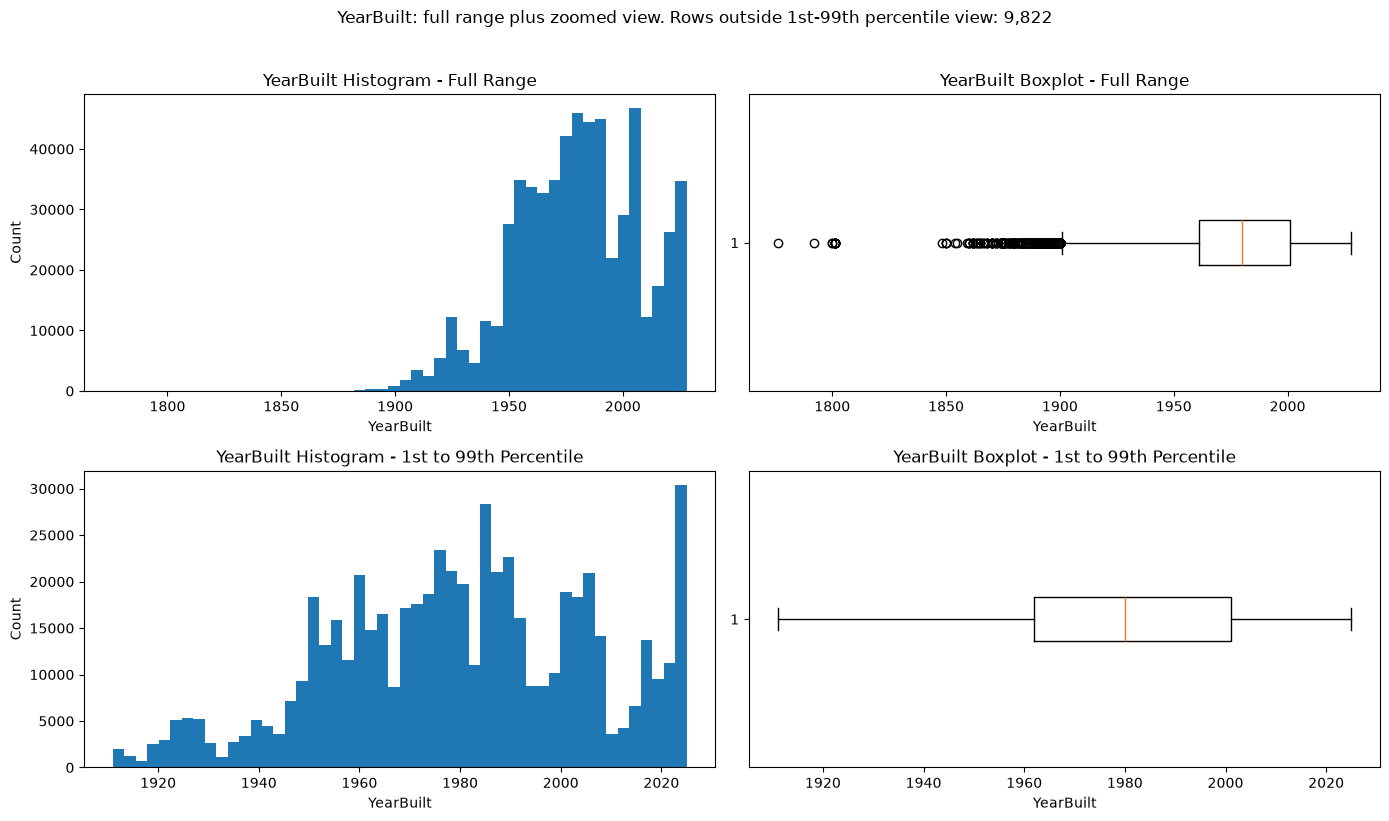

In [11]:
for field in numeric_fields:
    series = pd.to_numeric(listings_residential[field], errors="coerce").dropna()
    if series.empty:
        continue

    p01 = series.quantile(0.01)
    p99 = series.quantile(0.99)
    zoomed_series = series[(series >= p01) & (series <= p99)]
    outside_zoom_count = len(series) - len(zoomed_series)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].hist(series, bins=50)
    axes[0, 0].set_title(f"{field} Histogram - Full Range")
    axes[0, 0].set_xlabel(field)
    axes[0, 0].set_ylabel("Count")

    axes[0, 1].boxplot(series, vert=False, showfliers=True)
    axes[0, 1].set_title(f"{field} Boxplot - Full Range")
    axes[0, 1].set_xlabel(field)

    axes[1, 0].hist(zoomed_series, bins=50)
    axes[1, 0].set_title(f"{field} Histogram - 1st to 99th Percentile")
    axes[1, 0].set_xlabel(field)
    axes[1, 0].set_ylabel("Count")

    axes[1, 1].boxplot(zoomed_series, vert=False, showfliers=True)
    axes[1, 1].set_title(f"{field} Boxplot - 1st to 99th Percentile")
    axes[1, 1].set_xlabel(field)

    fig.suptitle(
        f"{field}: full range plus zoomed view. "
        f"Rows outside 1st-99th percentile view: {outside_zoom_count:,}",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{field}_full_and_zoomed_histogram_boxplot.png")
    plt.show()

## 9. Extreme Outlier Review

This uses the IQR rule to flag extreme values for later cleaning review. The notebook does not automatically remove outliers.

In [ ]:
outlier_rows = []

for field in numeric_fields:
    series = pd.to_numeric(listings_residential[field], errors="coerce").dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    low_outliers = int((series < lower_bound).sum())
    high_outliers = int((series > upper_bound).sum())
    
    outlier_rows.append({
        "field": field,
        # iqr is interquartile range, iqr = Q3 - Q1. lower_bound = Q1 - 1.5 * IQR, upper_bound = Q3 + 1.5 * IQR
        "iqr_lower_bound": lower_bound,
        "iqr_upper_bound": upper_bound,
        "low_outlier_count": low_outliers,
        "high_outlier_count": high_outliers,
        "total_outlier_count": low_outliers + high_outliers,
        "outlier_pct": round((low_outliers + high_outliers) / len(series) * 100, 2),
        "min": series.min(),
        "max": series.max(),
    })

outlier_report = pd.DataFrame(outlier_rows)
outlier_report

,field,iqr_lower_bound,iqr_upper_bound,low_outlier_count,high_outlier_count,total_outlier_count,outlier_pct,min,max
0,ListPrice,-625565.00000,2.591339e+06,0,49652,49652,8.40,1.0,4.000000e+08
1,OriginalListPrice,-630000.00000,2.610000e+06,0,48913,48913,8.28,0.0,1.390000e+09
2,LivingArea,-333.00000,3.883000e+03,0,29236,29236,4.95,0.0,1.702132e+07
3,LotSizeAcres,-0.17415,6.102500e-01,0,87005,87005,16.03,0.0,4.187292e+06
4,BedroomsTotal,-1.00000,7.000000e+00,0,1921,1921,0.32,0.0,9.400000e+01
5,BathroomsTotalInteger,0.50000,4.500000e+00,738,36884,37622,6.36,0.0,2.208000e+03
6,DaysOnMarket,-20.50000,4.750000e+01,4,48129,48133,8.14,-58.0,1.063000e+03
7,YearBuilt,1901.00000,2.061000e+03,1490,0,1490,0.25,1776.0,2.028000e+03


## 10. Answer Listing EDA Questions

In [13]:
list_price = pd.to_numeric(listings_residential["ListPrice"], errors="coerce")
original_list_price = pd.to_numeric(listings_residential["OriginalListPrice"], errors="coerce")
days_on_market = pd.to_numeric(listings_residential["DaysOnMarket"], errors="coerce")

listing_date = pd.to_datetime(listings_residential["ListingContractDate"], errors="coerce")
contract_status_date = pd.to_datetime(listings_residential["ContractStatusChangeDate"], errors="coerce")

valid_price_pairs = listings_residential[list_price.notna() & original_list_price.notna()].copy()
valid_price_pairs["ListPriceNumeric"] = pd.to_numeric(valid_price_pairs["ListPrice"], errors="coerce")
valid_price_pairs["OriginalListPriceNumeric"] = pd.to_numeric(valid_price_pairs["OriginalListPrice"], errors="coerce")

price_reduced_pct = (valid_price_pairs["ListPriceNumeric"] < valid_price_pairs["OriginalListPriceNumeric"]).mean() * 100
price_increased_pct = (valid_price_pairs["ListPriceNumeric"] > valid_price_pairs["OriginalListPriceNumeric"]).mean() * 100
price_unchanged_pct = (valid_price_pairs["ListPriceNumeric"] == valid_price_pairs["OriginalListPriceNumeric"]).mean() * 100

summary_answers = pd.DataFrame([
    {"question": "Average list price", "answer": list_price.mean()},
    {"question": "Median list price", "answer": list_price.median()},
    {"question": "Average OriginalListPrice", "answer": original_list_price.mean()},
    {"question": "Median OriginalListPrice", "answer": original_list_price.median()},
    {"question": "Average Days on Market", "answer": days_on_market.mean()},
    {"question": "Median Days on Market", "answer": days_on_market.median()},
    {"question": "Current list price below original list price pct", "answer": price_reduced_pct},
    {"question": "Current list price above original list price pct", "answer": price_increased_pct},
    {"question": "Current list price unchanged pct", "answer": price_unchanged_pct},
    {"question": "ContractStatusChangeDate before ListingContractDate rows", "answer": int((contract_status_date < listing_date).sum())},
])

summary_answers

,question,answer
0,Average list price,1.318434e+06
1,Median list price,8.488880e+05
2,Average OriginalListPrice,1.402465e+06
3,Median OriginalListPrice,8.490000e+05
4,Average Days on Market,1.869106e+01
5,Median Days on Market,1.100000e+01
6,Current list price below original list price pct,1.626843e+01
7,Current list price above original list price pct,2.855392e+00
8,Current list price unchanged pct,8.087617e+01
9,ContractStatusChangeDate before ListingContrac...,1.380000e+02


In [ ]:
county_median_list_prices = (
    listings_residential.assign(ListPriceNumeric=list_price)
    .dropna(subset=["CountyOrParish", "ListPriceNumeric"])
    .groupby("CountyOrParish")["ListPriceNumeric"]
    .median()
    .sort_values(ascending=False)
    .reset_index(name="median_list_price")
)

county_median_list_prices.head(10)

## 11. Save Deliverable Outputs

In [ ]:
filtered_output = PROCESSED_DIR / "crmls_listings_residential_week2_3_filtered_202401_202605.csv"

listings_residential.to_csv(filtered_output, index=False)
dtypes_summary.to_csv(REPORT_DIR / "dtypes_summary.csv", index=False)
property_type_counts.reset_index().to_csv(REPORT_DIR / "property_type_counts.csv", index=False)
field_classification.to_csv(REPORT_DIR / "field_classification.csv", index=False)
missing_report.to_csv(REPORT_DIR / "missing_value_report.csv", index=False)
numeric_summary.to_csv(REPORT_DIR / "numeric_distribution_summary.csv", index=False)
outlier_report.to_csv(REPORT_DIR / "numeric_outlier_report.csv", index=False)
summary_answers.to_csv(REPORT_DIR / "eda_question_answers.csv", index=False)
county_median_list_prices.to_csv(REPORT_DIR / "county_median_list_prices.csv", index=False)

print("Saved filtered dataset:", filtered_output)
print("Saved reports to:", REPORT_DIR)
print("Saved figures to:", FIGURE_DIR)